# Acceptance Rate Model — bản v1 để review

> **Notebook để TRÌNH BÀY.** Chạy `Run All` ~2 phút.
> Chi tiết kỹ thuật ở `00_TONG_HOP_chay_1_the` và `01`–`09`.

---

## Nội dung

| # | Phần | Trả lời |
|---|---|---|
| **1** | **Hướng tiếp cận** | Vì sao không train được model, chọn hướng nào thay thế |
| **2** | **Cách triển khai** | Công thức, tham số lấy từ đâu |
| **3** | **Kết quả ban đầu** | Trả lời gì được, vững đến đâu |
| **4** | **Giới hạn & câu hỏi** | Cần gì để đi tiếp |

---

## ⚠️ Ranh giới phải nói trước

> Đây **chưa phải** acceptance-rate predictor. Đây là **mô hình cấu trúc dưới giả định** —
> không train, không có nhãn để validate.
>
> Mọi con số dưới đây là **mô phỏng có điều kiện**, không phải xác suất đã hiệu chỉnh.

Ranh giới này trùng với kết luận độc lập của nhánh `acceptance_response_robustness v2.0.0`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5, "legend.fontsize": 10.5,
})
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ══════ MO HINH — toan bo "kien truc" chi co 4 dong ══════
P0 = 0.50                      # muc chap nhan khi gia ngang bang doi thu  [GIA DINH]
EPS = -2.0                     # elasticity firm-level                     [GIA DINH]
EPS_DAI = [-1.2, -2.0, -3.0]


def P_accept(ty_le, eps=EPS, P0=P0, dich_WTP=0.0):
    """ty_le = gia minh / gia doi thu."""
    b = eps / (1 - P0)
    a = np.log(P0 / (1 - P0))
    return 1 / (1 + np.exp(-(a + b * (np.log(ty_le) - np.log1p(dich_WTP)))))


assert abs(P_accept(1.0) - P0) < 1e-12
print(f"Mo hinh OK — tai gia ngang bang doi thu: P = {P_accept(1.0):.0%}")

# ══════ DO THAM SO TU DU LIEU ══════
cols = ["target_request_id", "gio_vn", "weather_main", "target_shown_multiplier"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
d = d.drop_duplicates(subset="target_request_id")
d["mua"] = d.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])

gm = d.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
gh = d.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = gh / gh.mean() - 1

print(f"\nDO TU DU LIEU ({len(d):,} chuyen, sau khu trung lap):")
print(f"  He so nhan  khong mua {gm[False]:.4f}  |  co mua {gm[True]:.4f}")
print(f"  => Dich WTP do MUA   : {DICH_MUA:+.2%}")
print(f"  => Dich WTP theo GIO : {DICH_GIO.min():+.1%} ({DICH_GIO.idxmin()}h) "
      f"-> {DICH_GIO.max():+.1%} ({DICH_GIO.idxmax()}h)")
print(f"     bien do {(gh.max()/gh.min()-1)*100:.1f}%")

Mo hinh OK — tai gia ngang bang doi thu: P = 50%



DO TU DU LIEU (1,724,714 chuyen, sau khu trung lap):
  He so nhan  khong mua 1.1414  |  co mua 1.1940
  => Dich WTP do MUA   : +4.61%
  => Dich WTP theo GIO : -25.2% (3h) -> +12.2% (18h)
     bien do 50.0%


## 1. Hướng tiếp cận

### Ràng buộc gốc

```
booking_or_completion_outcomes_generated = False
```

Đã quét **toàn bộ 70 cột**: không cột nào ghi nhận khách có đặt hay không. Đây là dữ liệu **báo giá**
(quote), không phải dữ liệu **giao dịch**.

### Đã thử và loại trừ 8 hướng

| # | Hướng | Bằng chứng loại trừ |
|---|---|---|
| 1 | Supervised learning | 0/251 cột có nhãn |
| 2 | Unsupervised | Acceptance không tồn tại dưới dạng ẩn nào |
| 3 | **Gán nhãn theo luật** | AUC **1,0000** → **0,4995** khi bỏ `price_gap` ⇒ vòng tròn logic |
| 4 | Proxy label từ cột khác | Đã quét hết 70 cột |
| 5 | PU learning | Cần vài mẫu dương — có **0** |
| 6 | Ước lượng cầu trực tiếp | Hồi quy thô ra hệ số **+0,40** — **sai dấu** (nội sinh) |
| 7 | Biến công cụ (IV) | Bỏ biến giờ ⇒ hệ số lật −0,95 → **+0,36** |
| 8 | Chỉ số Lerner | Cho `ε` = −33 đến −2,5 — vô lý |

**Hướng 3 đáng nói riêng** vì nghe rất hợp lý và đã được đề xuất từ bên ngoài. Đã cài đặt và chạy
thật: gán nhãn theo khoảng cách giá rồi train. Model chỉ **học lại đúng cái luật vừa dùng để tạo
nhãn** — không học gì từ dữ liệu.

### ⇒ Chuyển sang mô hình cấu trúc

Lý thuyết **lựa chọn rời rạc** (McFadden). Không train, không cần nhãn — công thức đến từ kinh tế
học, tham số hoặc **đo từ dữ liệu** hoặc **giả định có quét độ nhạy**.

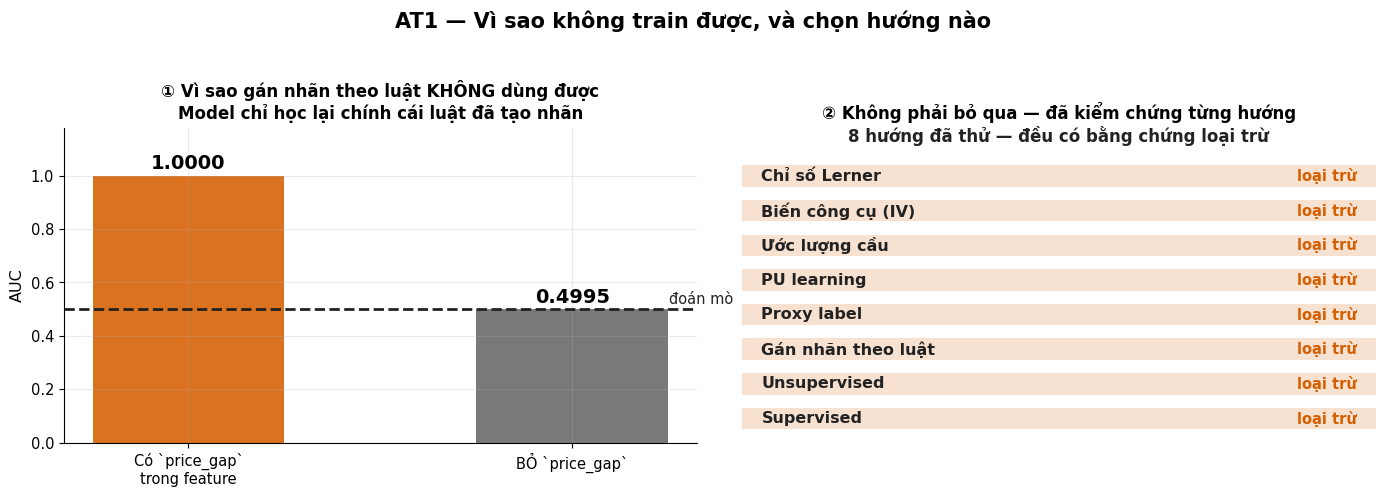

In [2]:
# ═════════ HINH AT1 — huong tiep can ═════════
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

# ① Vong tron logic
auc = [1.0000, 0.4995]
b = ax[0].bar(["Có `price_gap`\ntrong feature", "BỎ `price_gap`"], auc,
              color=[RED, MUT], alpha=.88, width=.5)
ax[0].axhline(.5, color=INK, lw=2, ls="--")
ax[0].text(1.42, .52, "đoán mò", fontsize=10.5, color=INK, ha="right")
for bb, v in zip(b, auc):
    ax[0].text(bb.get_x()+bb.get_width()/2, v+.025, f"{v:.4f}", ha="center",
               fontsize=14, fontweight="bold")
ax[0].set_ylabel("AUC"); ax[0].set_ylim(0, 1.18)
ax[0].set_title("① Vì sao gán nhãn theo luật KHÔNG dùng được\n"
                "Model chỉ học lại chính cái luật đã tạo nhãn",
                fontweight="bold", fontsize=12)

# ② 8 huong loai tru
huong = ["Supervised", "Unsupervised", "Gán nhãn theo luật", "Proxy label",
         "PU learning", "Ước lượng cầu", "Biến công cụ (IV)", "Chỉ số Lerner"]
ax[1].barh(range(8), [1]*8, color=RED, alpha=.18, height=.62)
for i, h in enumerate(huong):
    ax[1].text(.03, i, h, va="center", fontsize=11.5, fontweight="bold", color=INK)
    ax[1].text(.97, i, "loại trừ", va="center", ha="right", fontsize=10.5,
               color=RED, fontweight="bold")
ax[1].set_xlim(0, 1); ax[1].set_ylim(-.7, 8.4)
ax[1].set_xticks([]); ax[1].set_yticks([]); ax[1].grid(alpha=0)
for sp in ax[1].spines.values():
    sp.set_visible(False)
ax[1].text(.5, 8.0, "8 hướng đã thử — đều có bằng chứng loại trừ",
           ha="center", fontsize=12, fontweight="bold", color=INK)
ax[1].set_title("② Không phải bỏ qua — đã kiểm chứng từng hướng",
                fontweight="bold", fontsize=12)

fig.suptitle("AT1 — Vì sao không train được, và chọn hướng nào",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "AT1_huong_tiep_can.png"); plt.show()

## 2. Cách triển khai

### Công thức

$$P(\text{chấp nhận}) = \sigma\!\left(a + b\left[\ln\frac{p}{\hat p} - \ln(1+d)\right]\right)$$

| Ký hiệu | Nghĩa |
|---|---|
| `p` | Giá **mình** báo — biến quyết định |
| `p̂` | Giá **đối thủ** — từ model cấu phần (ii) |
| `d` | Dịch WTP theo bối cảnh |
| `ε` | Elasticity (firm-level) → `b = ε/(1−P₀)` |
| `P₀` | Chấp nhận khi giá ngang bằng → `a = logit(P₀)` |

### Bốn tham số — nguồn gốc rõ ràng

| Tham số | Nguồn | Giá trị |
|---|---|---|
| `p̂` | 📊 **Model cấu phần (ii)** | MAE 18.045đ |
| `d` | 📊 **ĐO TỪ DỮ LIỆU** | mưa +4,61% · giờ biên độ 50,0% |
| `P₀` | ⚠️ Quy ước | 0,50 |
| `ε` | ⚠️ **Giả định** | −2,0 (quét −1,2 → −3,0) |

**Chỉ 2/4 tham số là giả định**, cả hai đều quét dải độ nhạy.

### Vì sao hệ số nhân đo được WTP

Hệ số nhân là **giá cân bằng**. Nếu lúc 18h giá cân bằng cao hơn trung bình 12,2% mà chuyến vẫn
diễn ra, điều đó **bộc lộ** khách lúc đó chấp nhận trả cao hơn — *revealed preference*.

⚠️ Hạn chế: hệ số nhân cao đến từ **cả** cầu tăng **và** cung khan. Nên `d` là **cận trên** của
dịch WTP thật, không phải giá trị chính xác.

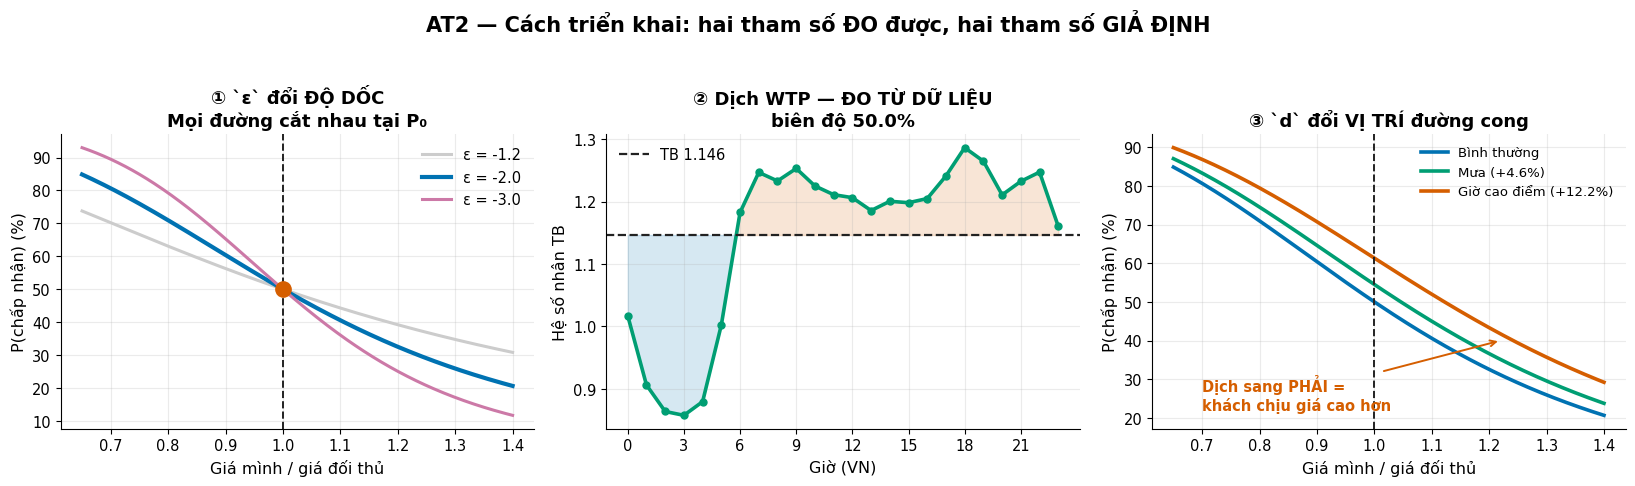

In [3]:
# ═════════ HINH AT2 — cach trien khai ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.7))
r = np.linspace(.65, 1.4, 300)

# ① Elasticity doi DO DOC
for e, col, lw in zip([-1.2, -2.0, -3.0], [LIGHT, BLUE, PURPLE], [2.2, 3.0, 2.2]):
    ax[0].plot(r, P_accept(r, e)*100, color=col, lw=lw, label=f"ε = {e}")
ax[0].axvline(1.0, color=INK, lw=1.4, ls="--")
ax[0].plot(1.0, 50, "o", color=RED, ms=11, zorder=5)
ax[0].set_xlabel("Giá mình / giá đối thủ"); ax[0].set_ylabel("P(chấp nhận) (%)")
ax[0].legend(frameon=False)
ax[0].set_title("① `ε` đổi ĐỘ DỐC\nMọi đường cắt nhau tại P₀", fontweight="bold")

# ② Dich WTP DO TU DU LIEU
ax[1].plot(gh.index, gh.values, marker="o", lw=2.6, ms=5, color=GREEN)
ax[1].axhline(gh.mean(), color=INK, lw=1.6, ls="--", label=f"TB {gh.mean():.3f}")
ax[1].fill_between(gh.index, gh.mean(), gh.values, where=(gh.values >= gh.mean()),
                   color=RED, alpha=.16, interpolate=True)
ax[1].fill_between(gh.index, gh.mean(), gh.values, where=(gh.values < gh.mean()),
                   color=BLUE, alpha=.16, interpolate=True)
ax[1].set_xticks(range(0, 24, 3)); ax[1].set_xlabel("Giờ (VN)")
ax[1].set_ylabel("Hệ số nhân TB"); ax[1].legend(frameon=False)
ax[1].set_title(f"② Dịch WTP — ĐO TỪ DỮ LIỆU\nbiên độ {(gh.max()/gh.min()-1)*100:.1f}%",
                fontweight="bold")

# ③ Dich WTP doi VI TRI
for dd, col, ten in [(0.0, BLUE, "Bình thường"),
                     (DICH_MUA, GREEN, f"Mưa ({DICH_MUA:+.1%})"),
                     (DICH_GIO.max(), RED, f"Giờ cao điểm ({DICH_GIO.max():+.1%})")]:
    ax[2].plot(r, P_accept(r, dich_WTP=dd)*100, color=col, lw=2.6, label=ten)
ax[2].axvline(1.0, color=INK, lw=1.4, ls="--")
ax[2].annotate("Dịch sang PHẢI =\nkhách chịu giá cao hơn", xy=(1.22, 40),
               xytext=(.70, 22), fontsize=10.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.4))
ax[2].set_xlabel("Giá mình / giá đối thủ"); ax[2].set_ylabel("P(chấp nhận) (%)")
ax[2].legend(frameon=False, fontsize=9.5)
ax[2].set_title("③ `d` đổi VỊ TRÍ đường cong", fontweight="bold")

fig.suptitle("AT2 — Cách triển khai: hai tham số ĐO được, hai tham số GIẢ ĐỊNH",
             fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "AT2_trien_khai.png"); plt.show()

## 3. Kết quả ban đầu

### Cách trình bày — dùng **% thay đổi tương đối**

Mức tuyệt đối phụ thuộc nặng vào `P₀` — tham số giả định. Đã kiểm cho `P₀` chạy 0,30 → 0,70:

| Cách báo cáo | Dao động khi đổi `P₀` |
|---|---:|
| Mức tuyệt đối | **30,7 điểm** ❌ |
| **Thay đổi tương đối** | **3,1 điểm** ✅ |

⇒ Mọi kết luận phát biểu theo **% thay đổi tương đối** — robust gấp 10 lần.

In [4]:
MOC = [-.20, -.15, -.10, -.05, 0, .05, .10, .15, .20]
P0_KIEM = [.30, .40, .50, .60, .70]


def tuong_doi(p, eps=EPS, P0_=P0):
    return P_accept(1+p, eps, P0_) / P_accept(1.0, eps, P0_) - 1


rows = []
for p in MOC:
    v = [tuong_doi(p, EPS, x) for x in P0_KIEM]
    rows.append({"Đổi giá": f"{p:+.0%}",
                 "Chấp nhận (tương đối)": f"{np.mean(v):+.0%}",
                 "Dao động theo P₀": f"{min(v):+.1%} … {max(v):+.1%}"})
print("MODEL 1 — khi biet GIA DOI THU")
display(pd.DataFrame(rows).set_index("Đổi giá"))

P_k = P_accept(1.0, dich_WTP=0.0)
P_m = P_accept(1.0, dich_WTP=DICH_MUA)
Pg = np.array([P_accept(1.0, dich_WTP=DICH_GIO[h]) for h in range(24)])
bd_mua, bd_gio = (P_m-P_k)*100, (Pg.max()-Pg.min())*100
print(f"\nMODEL 2 — khi biet THOI TIET")
print(f"  Mua -> chap nhan TANG {bd_mua:+.2f} diem %")
print(f"     (tuong duong: tang gia duoc ~{DICH_MUA:.1%} ma khong mat khach)")
print(f"\n  Bien do THOI TIET : {bd_mua:5.2f} diem %")
print(f"  Bien do GIO       : {bd_gio:5.2f} diem %  <- manh hon {bd_gio/bd_mua:.1f} lan")

MODEL 1 — khi biet GIA DOI THU


,Chấp nhận (tương đối),Dao động theo P₀
Đổi giá,,
-20%,+41%,+30.2% … +49.3%
-15%,+31%,+24.8% … +35.1%
-10%,+20%,+17.8% … +22.2%
-5%,+10%,+9.5% … +10.5%
+0%,+0%,+0.0% … +0.0%
+5%,-10%,-10.3% … -9.5%
+10%,-19%,-21.0% … -18.0%
+15%,-28%,-31.6% … -25.6%
+20%,-36%,-41.6% … -32.4%



MODEL 2 — khi biet THOI TIET
  Mua -> chap nhan TANG +4.49 diem %
     (tuong duong: tang gia duoc ~4.6% ma khong mat khach)

  Bien do THOI TIET :  4.49 diem %
  Bien do GIO       : 37.48 diem %  <- manh hon 8.3 lan


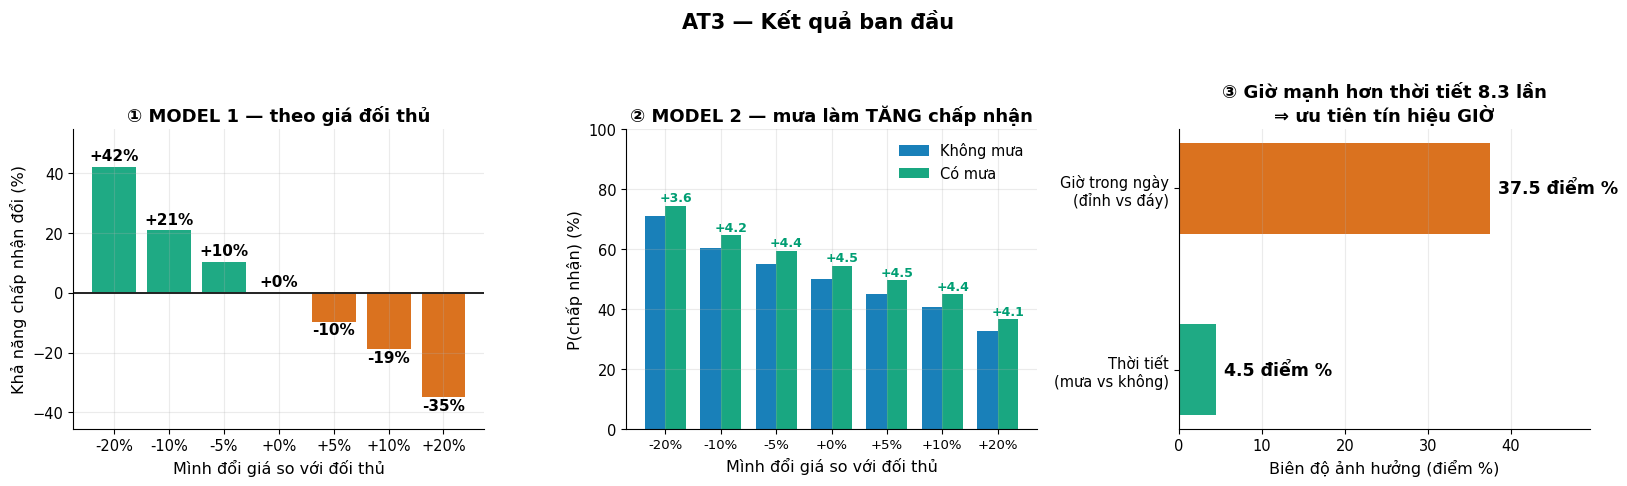

In [5]:
# ═════════ HINH AT3 — ket qua ═════════
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.7))
MOC_VE = [-.20, -.10, -.05, 0, .05, .10, .20]

v = [tuong_doi(p)*100 for p in MOC_VE]
b = ax[0].bar(range(len(MOC_VE)), v,
              color=[GREEN if x > 0 else (MUT if x == 0 else RED) for x in v], alpha=.88)
for bb, x_ in zip(b, v):
    ax[0].text(bb.get_x()+bb.get_width()/2, x_ + (2.2 if x_ >= 0 else -4.2),
               f"{x_:+.0f}%", ha="center", fontsize=11, fontweight="bold")
ax[0].axhline(0, color=INK, lw=1.4)
ax[0].set_xticks(range(len(MOC_VE)))
ax[0].set_xticklabels([f"{p:+.0%}" for p in MOC_VE])
ax[0].set_xlabel("Mình đổi giá so với đối thủ")
ax[0].set_ylabel("Khả năng chấp nhận đổi (%)")
ax[0].set_ylim(min(v)*1.3, max(v)*1.3)
ax[0].set_title("① MODEL 1 — theo giá đối thủ", fontweight="bold")

x2 = np.arange(len(MOC_VE)); w = .37
vk = [P_accept(1+p)*100 for p in MOC_VE]
vm = [P_accept(1+p, dich_WTP=DICH_MUA)*100 for p in MOC_VE]
ax[1].bar(x2-w/2, vk, w, color=BLUE, alpha=.9, label="Không mưa")
b2 = ax[1].bar(x2+w/2, vm, w, color=GREEN, alpha=.9, label="Có mưa")
for bb, a_, b_ in zip(b2, vk, vm):
    ax[1].text(bb.get_x()+bb.get_width()/2, b_+1.4, f"+{b_-a_:.1f}", ha="center",
               fontsize=9, color=GREEN, fontweight="bold")
ax[1].set_xticks(x2); ax[1].set_xticklabels([f"{p:+.0%}" for p in MOC_VE], fontsize=9.5)
ax[1].set_xlabel("Mình đổi giá so với đối thủ")
ax[1].set_ylabel("P(chấp nhận) (%)"); ax[1].set_ylim(0, 100)
ax[1].legend(frameon=False)
ax[1].set_title("② MODEL 2 — mưa làm TĂNG chấp nhận", fontweight="bold")

bb2 = ax[2].barh(["Thời tiết\n(mưa vs không)", "Giờ trong ngày\n(đỉnh vs đáy)"],
                 [bd_mua, bd_gio], color=[GREEN, RED], alpha=.88, height=.5)
for r_, v_ in zip(bb2, [bd_mua, bd_gio]):
    ax[2].text(v_+.9, r_.get_y()+r_.get_height()/2, f"{v_:.1f} điểm %",
               va="center", fontsize=12.5, fontweight="bold")
ax[2].set_xlabel("Biên độ ảnh hưởng (điểm %)")
ax[2].set_xlim(0, bd_gio*1.32); ax[2].grid(axis="y", alpha=0)
ax[2].set_title(f"③ Giờ mạnh hơn thời tiết {bd_gio/bd_mua:.1f} lần\n"
                "⇒ ưu tiên tín hiệu GIỜ", fontweight="bold")

fig.suptitle("AT3 — Kết quả ban đầu", fontweight="bold", fontsize=15, y=1.03)
plt.tight_layout(); plt.savefig(HINH / "AT3_ket_qua.png"); plt.show()

### Ba kết luận có **vững** trên toàn dải giả định không?

In [6]:
rows = []
for e in EPS_DAI:
    Pk = P_accept(1.0, e); Pm = P_accept(1.0, e, dich_WTP=DICH_MUA)
    Pg_ = np.array([P_accept(1.0, e, dich_WTP=DICH_GIO[h]) for h in range(24)])
    rows.append({
        "ε": e,
        "+10% giá → chấp nhận": f"{P_accept(1.10, e)/P_accept(1.0, e)-1:+.0%}",
        "1. Giá cao hơn → GIẢM?": "CÓ" if P_accept(1.10, e) < P_accept(1.0, e) else "không",
        "2. Mưa → TĂNG?": "CÓ" if Pm > Pk else "không",
        "3. Giờ mạnh hơn thời tiết?": "CÓ" if (Pg_.max()-Pg_.min()) > (Pm-Pk) else "không",
    })
DS = pd.DataFrame(rows)
display(DS.set_index("ε"))

n = len(DS)
print("KIEM TRA TINH VUNG:")
for c in ["1. Giá cao hơn → GIẢM?", "2. Mưa → TĂNG?", "3. Giờ mạnh hơn thời tiết?"]:
    print(f"  {c:32s} {DS[c].eq('CÓ').sum()}/{n}")
print("\n=> Ca 3 ket luan KHONG phu thuoc gia tri elasticity cu the.")
print("   Muc TUYET DOI thi phu thuoc; CHIEU va THU TU DO LON thi khong.")

,+10% giá → chấp nhận,1. Giá cao hơn → GIẢM?,2. Mưa → TĂNG?,3. Giờ mạnh hơn thời tiết?
ε,,,,
-1.2,-11%,CÓ,CÓ,CÓ
-2.0,-19%,CÓ,CÓ,CÓ
-3.0,-28%,CÓ,CÓ,CÓ


KIEM TRA TINH VUNG:
  1. Giá cao hơn → GIẢM?           3/3
  2. Mưa → TĂNG?                   3/3
  3. Giờ mạnh hơn thời tiết?       3/3

=> Ca 3 ket luan KHONG phu thuoc gia tri elasticity cu the.
   Muc TUYET DOI thi phu thuoc; CHIEU va THU TU DO LON thi khong.


### Kiểm chứng chéo — hai nguồn độc lập

| Cách | Kết quả |
|---|---|
| **MNL 3 lựa chọn** `{không đi, mình, đối thủ}` | Khớp logit nhị phân trong **3 điểm %**; suy ngược ra tỷ lệ khách không đặt `s₀` = **14,3%** (nằm trong khoảng hợp lý 5–30%) |
| **Đối chiếu literature** | Cohen 2016 (UberX, RD quanh ngưỡng surge): `ε ≈ −1,6` — cùng bậc với dải giả định [−1,2; −3,0] |

MNL còn bắt được **một cặp giả định không nhất quán** mà logit nhị phân không phát hiện được:
`ε_firm = −1,2` + `ε_market = −0,7` cho `s₀ = 41,2%` — vô lý.

⚠️ Số literature ghi từ trí nhớ, **chưa đối chiếu bản gốc**.

---

## 4. Giới hạn & câu hỏi

In [7]:
print("╔" + "═"*72 + "╗")
print("║" + " ACCEPTANCE MODEL v1 — TOM TAT ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print("  LAM DUOC GI:")
for p in [.05, .10, .20]:
    print(f"    Tang gia {p:+.0%} so voi doi thu  ->  chap nhan {tuong_doi(p):+.0%}")
print(f"    Troi mua                      ->  chap nhan {bd_mua:+.1f} diem %")
print(f"    Gio manh hon thoi tiet {bd_gio/bd_mua:.1f} lan  ->  uu tien tin hieu GIO")
print()
print("  DO VUNG: ca 3 ket luan giu nguyen tren toan dai elasticity (3/3)")
print()
print("  KHONG LAM DUOC:")
print("    · Khong noi duoc con so TUYET DOI dang tin (phu thuoc P0)")
print("    · Khong khuyen nghi duoc GIA cu the (phu thuoc chi phi bien)")
print("    · Khong validate duoc (khong co nhan)")
print()
print("─"*74)
print("  RANH GIOI: day la MO PHONG DUOI GIA DINH, khong phai predictor da hieu chinh.")
print("─"*74)

╔════════════════════════════════════════════════════════════════════════╗
║                     ACCEPTANCE MODEL v1 — TOM TAT                      ║
╚════════════════════════════════════════════════════════════════════════╝

  LAM DUOC GI:
    Tang gia +5% so voi doi thu  ->  chap nhan -10%
    Tang gia +10% so voi doi thu  ->  chap nhan -19%
    Tang gia +20% so voi doi thu  ->  chap nhan -35%
    Troi mua                      ->  chap nhan +4.5 diem %
    Gio manh hon thoi tiet 8.3 lan  ->  uu tien tin hieu GIO

  DO VUNG: ca 3 ket luan giu nguyen tren toan dai elasticity (3/3)

  KHONG LAM DUOC:
    · Khong noi duoc con so TUYET DOI dang tin (phu thuoc P0)
    · Khong khuyen nghi duoc GIA cu the (phu thuoc chi phi bien)
    · Khong validate duoc (khong co nhan)

──────────────────────────────────────────────────────────────────────────
  RANH GIOI: day la MO PHONG DUOI GIA DINH, khong phai predictor da hieu chinh.
────────────────────────────────────────────────────────────────────

### Ba giới hạn

| # | Giới hạn | Mức |
|---|---|---|
| **1** | Dữ liệu **không có nhãn accept/reject** ⇒ không validate được | 🔴 |
| **2** | **Chi phí biên chưa biết** ⇒ chưa khuyến nghị được giá cụ thể | 🔴 |
| **3** | `d` là **cận trên** của WTP (lẫn hiệu ứng phía cung) | 🟠 |

### Bốn câu hỏi cần mentor

| # | Câu hỏi | Mở khoá |
|---|---|---|
| **1** | **Chi phí biên mỗi cuốc / tỷ lệ ăn chia tài xế?** | Chốt **chiều** của khuyến nghị giá |
| **2** | Team tối ưu **GMV** hay **lợi nhuận**? | Chọn hàm mục tiêu |
| **3** | **% khách xem giá rồi không đặt** (`s₀`) + thị phần? | Chốt `β` ⇒ hết phải giả định elasticity |
| **4** | Có bộ dữ liệu **`giá đã hiện` + `outcome`** không? | Mở khoá supervised — biến mô phỏng thành predictor |

> **Nếu chỉ trả lời được 2: xin câu 1 và câu 3.**

### Đối chiếu với nhánh robustness v2.0.0

Hai hướng làm **độc lập**, ra **cùng kết luận nền tảng**: chưa thể train acceptance predictor.

| | Nhánh robustness v2 | Bản này |
|---|---|---|
| Xử lý giả định | Quét 26.973 tổ hợp, 3 dạng hàm liên kết | Quét dải `ε`, `P₀`, `c`; chỉ logit |
| Tham số bối cảnh | **Giả định** (stress test) | **Đo từ dữ liệu** |
| Neo `ε` | Không neo | Literature + ràng buộc MNL |
| Kết luận vận hành | **ABSTAIN** | Có điều kiện — phụ thuộc chi phí biên |

Hai kết luận **không mâu thuẫn**: nhánh v2 nói *economics fragile, assumptions đảo được dấu*.
Bản này chỉ ra **chính xác cái gì đảo dấu** — chi phí biên, ngưỡng `c* = 50%`.

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `AT1_huong_tiep_can` | Vòng tròn logic · 8 hướng đã loại trừ |
| `AT2_trien_khai` | Cơ chế · dịch WTP đo từ dữ liệu |
| `AT3_ket_qua` | Model 1 · Model 2 · giờ vs thời tiết |

## Chi tiết kỹ thuật

| Notebook | Nội dung |
|---|---|
| `00_TONG_HOP_chay_1_the` | Bản đầy đủ — chạy 1 thể |
| `05_thu_nghiem_pseudo_label` | Bác bỏ gán nhãn theo luật |
| `07_chiphi_bien_va_uncertainty` | Chi phí biên + tích phân trên phân phối dự đoán |
| `08_MNL_ba_lua_chon` · `09_doi_chieu_literature` | Kiểm chứng chéo |